# Linear Regression from Scratch — NumPy

We implement **batch gradient descent** for linear regression using only NumPy —
no scikit-learn. Building it yourself forces you to understand exactly what every
library call is doing under the hood.

**Algorithm:**
$$\boldsymbol{\theta} := \boldsymbol{\theta} - \alpha \frac{1}{m} X^T (X\boldsymbol{\theta} - \mathbf{y})$$

where $\alpha$ is the learning rate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../..')
from src.utils import set_style, plot_cost_history, regression_report

set_style()
np.random.seed(42)

## 1. Generate Synthetic Data

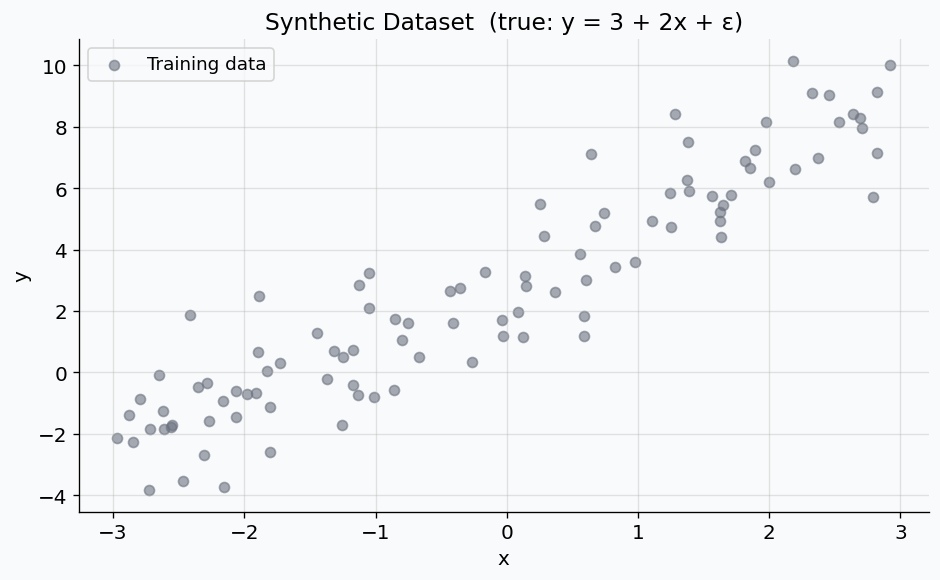

In [2]:
# True relationship: y = 3 + 2*x + noise
m = 100
x = np.random.uniform(-3, 3, m)
y = 3 + 2 * x + np.random.randn(m) * 1.5

# Design matrix with bias column
X = np.column_stack([np.ones(m), x])  # (100, 2)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, color='#6B7280', label='Training data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Dataset  (true: y = 3 + 2x + ε)')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Gradient Descent Implementation

In [3]:
def compute_cost(X: np.ndarray, y: np.ndarray, theta: np.ndarray) -> float:
    """J(θ) = (1/2m) ||Xθ - y||²"""
    m = len(y)
    r = X @ theta - y
    return float(r @ r) / (2 * m)


def gradient_descent(
    X: np.ndarray,
    y: np.ndarray,
    alpha: float = 0.01,
    n_iterations: int = 1000,
) -> tuple[np.ndarray, list[float]]:
    """
    Batch gradient descent for linear regression.

    Update rule (vectorised):
        θ := θ - (α/m) Xᵀ(Xθ - y)

    Returns:
        theta       — optimised parameters
        cost_history — J per iteration
    """
    m, n = X.shape
    theta = np.zeros(n)          # initialise all weights to 0
    cost_history: list[float] = []

    for _ in range(n_iterations):
        residuals = X @ theta - y        # (m,)
        gradient  = X.T @ residuals / m  # (n,)  — vectorised over all samples
        theta     = theta - alpha * gradient
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

## 3. Train & Verify Convergence

Learned θ: intercept=2.9778, slope=1.8851
True      : intercept=3.0000, slope=2.0000


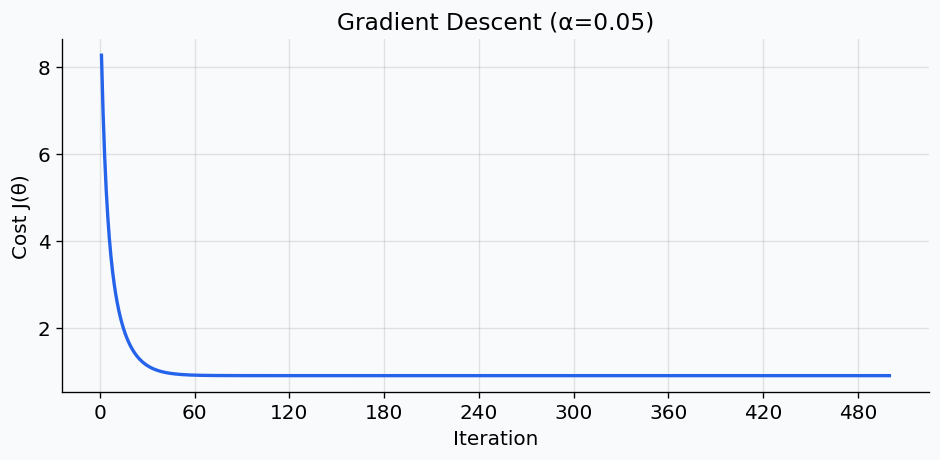

In [4]:
alpha       = 0.05
n_iter      = 500

theta_gd, cost_hist = gradient_descent(X, y, alpha=alpha, n_iterations=n_iter)

print(f'Learned θ: intercept={theta_gd[0]:.4f}, slope={theta_gd[1]:.4f}')
print(f'True      : intercept=3.0000, slope=2.0000')

plot_cost_history(cost_hist, title=f'Gradient Descent (α={alpha})')

## 4. Learning Rate Sensitivity

Too large → diverges. Too small → very slow. Finding the right $\alpha$ is an art.

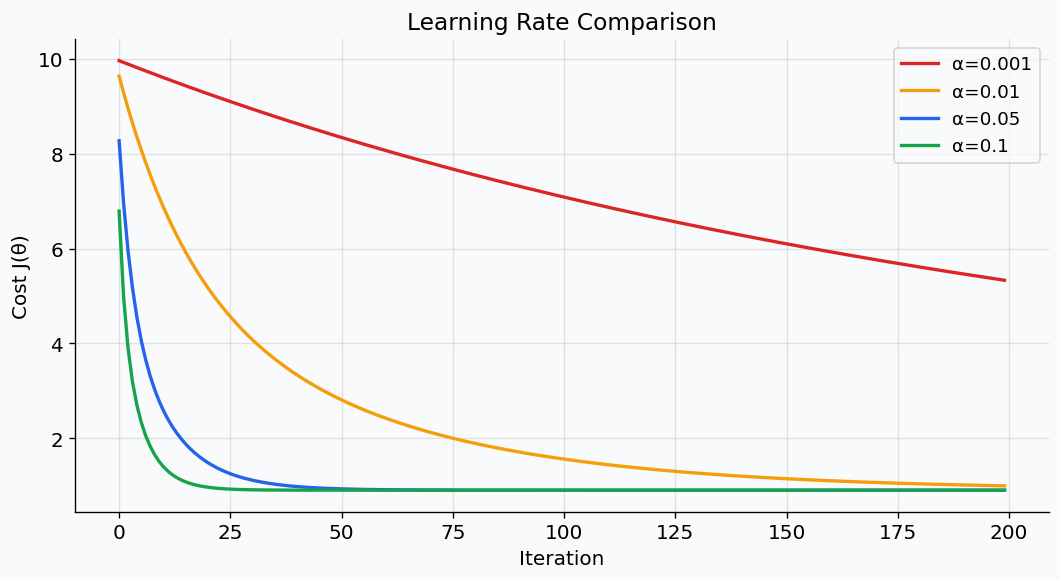

In [5]:
alphas = [0.001, 0.01, 0.05, 0.1]
colors = ['#DC2626', '#F59E0B', '#2563EB', '#16A34A']

fig, ax = plt.subplots(figsize=(9, 5))
for a, c in zip(alphas, colors):
    _, hist = gradient_descent(X, y, alpha=a, n_iterations=200)
    ax.plot(hist, color=c, lw=2, label=f'α={a}')

ax.set_xlabel('Iteration')
ax.set_ylabel('Cost J(θ)')
ax.set_title('Learning Rate Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Evaluate the Model

Regression metrics:
  MSE  : 1.8148
  RMSE : 1.3472
  MAE  : 1.0516
  R²   : 0.8606


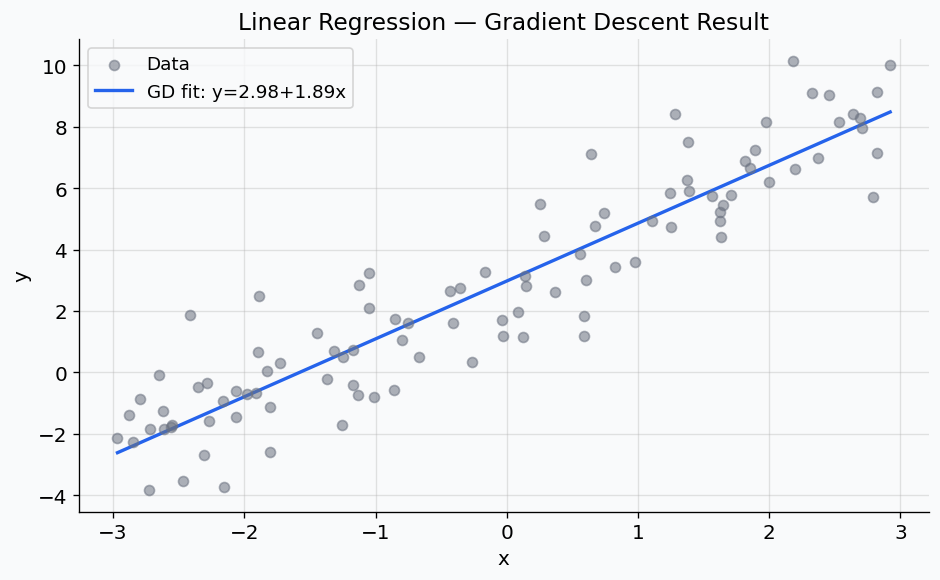

In [6]:
y_pred = X @ theta_gd
print('Regression metrics:')
regression_report(y, y_pred)

# Fit line
x_line = np.linspace(x.min(), x.max(), 200)
y_line = theta_gd[0] + theta_gd[1] * x_line

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.55, color='#6B7280', label='Data', zorder=3)
ax.plot(x_line, y_line, color='#2563EB', lw=2,
        label=f'GD fit: y={theta_gd[0]:.2f}+{theta_gd[1]:.2f}x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear Regression — Gradient Descent Result')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Compare to Normal Equation

In [7]:
theta_ols, *_ = np.linalg.lstsq(X, y, rcond=None)

print(f'Gradient Descent θ: {theta_gd}')
print(f'Normal Equation  θ: {theta_ols}')
print(f'Difference         : {np.abs(theta_gd - theta_ols)}')

Gradient Descent θ: [2.97781432 1.88505669]
Normal Equation  θ: [2.97781432 1.88505669]
Difference         : [3.31752403e-11 2.69695377e-12]


## Summary

We implemented linear regression gradient descent from scratch:

```
gradient = Xᵀ(Xθ - y) / m      ← vectorised over all m samples
θ        = θ - α * gradient      ← parameter update
```

Key takeaways:
- The gradient is a vector; one update step moves $\boldsymbol{\theta}$ in all dimensions simultaneously.
- The learning rate $\alpha$ must be tuned — too large diverges, too small wastes iterations.
- For small datasets, the Normal Equation gives the exact answer instantly.

**Next:** [scikit-learn implementation →](03_sklearn_implementation.ipynb)